<a href="https://colab.research.google.com/github/Gabriel-idkw/Customer-Behavior-Prediction/blob/main/04_gmm_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 04 — Gaussian Mixture Models (GMM)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json, itertools, time
import joblib
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
RANDOM_STATE = 42
FORCED_K = 4


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Load Baseline

In [3]:
df_full = pd.read_csv('/content/drive/MyDrive/project/data/preprocessed_rfm_scaled.csv')
feature_cols = ['Recency_scaled', 'Frequency_log_scaled', 'Monetary_log_scaled', 'AOV_scaled', 'Return_Rate_Pct_scaled']
print(f"Full baseline: {df_full.shape[0]:,} customers x {len(feature_cols)} features")

SAMPLE_SIZE = 10000
df = df_full.sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE).reset_index(drop=True)
X = df[feature_cols].values
print(f"Working sample for GMM clustering: {X.shape[0]:,} customers")


Full baseline: 49,661 customers x 5 features
Working sample for GMM clustering: 10,000 customers


## 2. Grid Search Implementation
Search across probabilistic hyperparameters:
- **Number of Components (N):** 2 - 8
- **Covariance Types:** full, tied, diag, spherical

In [4]:
param_grid = {'n_components': list(range(2, 9)), 'covariance_type': ['full', 'tied', 'diag', 'spherical']}

SIL_SAMPLE = 5000
sil_idx = np.random.RandomState(RANDOM_STATE).choice(len(X), size=SIL_SAMPLE, replace=False)

results = []
start = time.time()
for n_components, cov_type in itertools.product(param_grid['n_components'], param_grid['covariance_type']):
    model = GaussianMixture(n_components=n_components, covariance_type=cov_type, random_state=RANDOM_STATE, n_init=3)
    labels = model.fit_predict(X)
    sil = silhouette_score(X[sil_idx], labels[sil_idx])
    db = davies_bouldin_score(X, labels)
    ch = calinski_harabasz_score(X, labels)
    bic = model.bic(X)
    aic = model.aic(X)
    results.append({
        'n_components': n_components, 'covariance_type': cov_type,
        'silhouette': sil, 'davies_bouldin': db, 'calinski_harabasz': ch,
        'bic': bic, 'aic': aic,
    })

results_df = pd.DataFrame(results)
print(f"Grid search complete: {len(results_df)} combinations in {time.time()-start:.1f}s")
results_df.sort_values('silhouette', ascending=False).head(10)


Grid search complete: 28 combinations in 32.7s


,n_components,covariance_type,silhouette,davies_bouldin,calinski_harabasz,bic,aic
1,2,tied,0.326064,1.649998,1262.503846,96764.056255,96576.587406
3,2,spherical,0.297574,1.528964,3835.113377,131165.484086,131071.749661
2,2,diag,0.294983,1.507198,3932.033723,128823.429718,128672.012570
5,3,tied,0.292766,1.579743,1783.012063,95186.980386,94956.249494
9,4,tied,0.269430,1.463276,1458.198004,92646.894863,92372.901929
0,2,full,0.266086,1.988587,2283.692862,82300.277735,82004.653780
13,5,tied,0.257805,2.194674,1060.993571,86677.993970,86360.738993
4,3,full,0.224889,2.090820,1752.374850,67180.724092,66733.682989
21,7,tied,0.212892,2.013151,1234.983549,90919.647667,90515.868606
17,6,tied,0.207091,1.944353,1326.993132,90875.187633,90514.670615


## 3. Record Evaluation Metrics
Silhouette Score, Davies-Bouldin, Calinski-Harabasz, plus the probabilistic model-selection criteria BIC and AIC (both lower-is-better).

In [5]:
search_pool = results_df[results_df['n_components'] == FORCED_K] if FORCED_K is not None else results_df
if FORCED_K is not None:
    print(f"FORCED_K={FORCED_K}: selecting the best hyperparameters among the {len(search_pool)} "
          f"grid combinations run at N={FORCED_K} (out of {len(results_df)} total).")

best_row = search_pool.sort_values('silhouette', ascending=False).iloc[0]
best_bic_row = search_pool.sort_values('bic').iloc[0]

print("Best by Silhouette Score:")
print(f"  N = {int(best_row['n_components'])}, covariance = {best_row['covariance_type']}, silhouette = {best_row['silhouette']:.4f}")
print(f"\nBest by BIC among N={FORCED_K} (lowest information loss):" if FORCED_K is not None else "\nBest by BIC (lowest information loss):")
print(f"  N = {int(best_bic_row['n_components'])}, covariance = {best_bic_row['covariance_type']}, BIC = {best_bic_row['bic']:.1f}")

best_n = int(best_row['n_components'])
best_cov = best_row['covariance_type']


FORCED_K=4: selecting the best hyperparameters among the 4 grid combinations run at N=4 (out of 28 total).
Best by Silhouette Score:
  N = 4, covariance = tied, silhouette = 0.2694

Best by BIC among N=4 (lowest information loss):
  N = 4, covariance = full, BIC = 61639.0


In [6]:
best_model = GaussianMixture(n_components=best_n, covariance_type=best_cov, random_state=RANDOM_STATE, n_init=3)
cluster_labels = best_model.fit_predict(X)
cluster_probs = best_model.predict_proba(X)
df['cluster'] = cluster_labels
df['cluster'].value_counts().sort_index()


,count
cluster,
0,561
1,1494
2,202
3,7743


## 4. Generate Visualizations
### BIC/AIC Curves

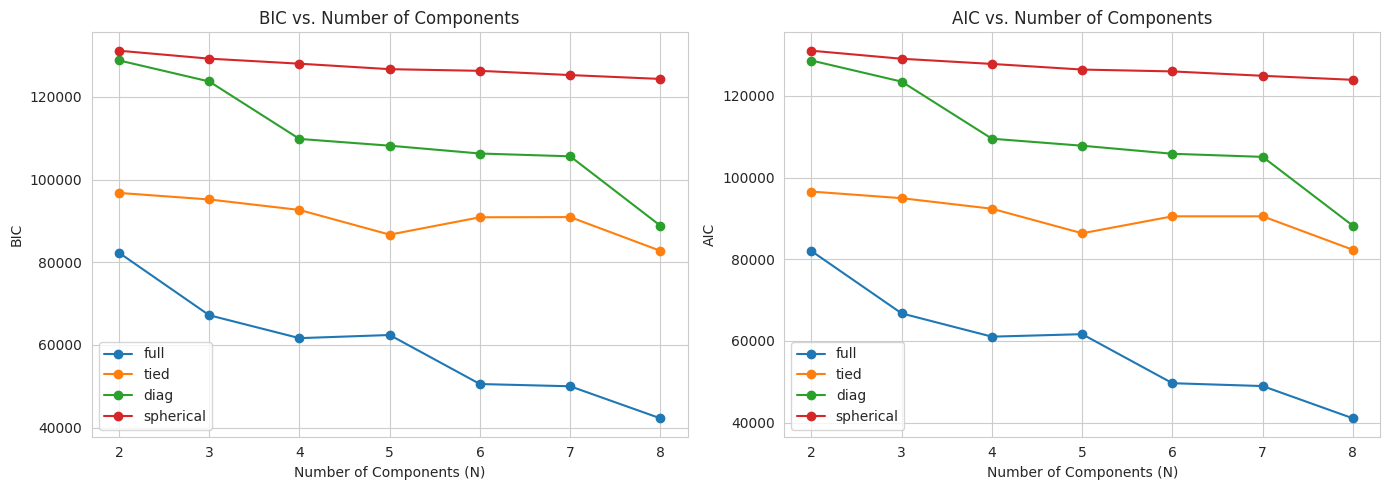

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric, title in zip(axes, ['bic', 'aic'], ['BIC', 'AIC']):
    for cov_type in param_grid['covariance_type']:
        subset = results_df[results_df['covariance_type'] == cov_type].sort_values('n_components')
        ax.plot(subset['n_components'], subset[metric], marker='o', label=cov_type)
    ax.set_xlabel('Number of Components (N)')
    ax.set_ylabel(title)
    ax.set_title(f'{title} vs. Number of Components')
    ax.legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/project/data/gmm_bic_aic_curves.png', dpi=110)
plt.show()


### Probability Uncertainty Plot

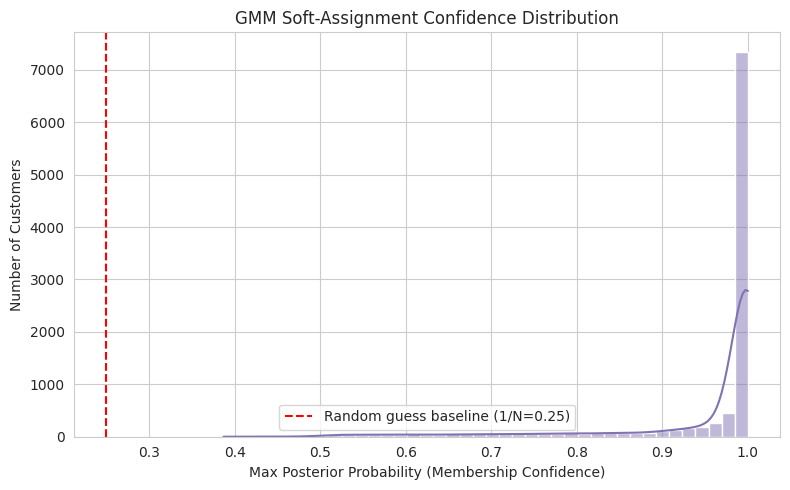

In [8]:
max_proba = cluster_probs.max(axis=1)

plt.figure(figsize=(8, 5))
sns.histplot(max_proba, bins=40, kde=True, color='#8172B2')
plt.axvline(1/best_n, color='red', linestyle='--', label=f'Random guess baseline (1/N={1/best_n:.2f})')
plt.xlabel('Max Posterior Probability (Membership Confidence)')
plt.ylabel('Number of Customers')
plt.title('GMM Soft-Assignment Confidence Distribution')
plt.legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/project/data/gmm_uncertainty.png', dpi=110)
plt.show()


### 2D PCA Scatter Plot (Hard-Assigned Labels)

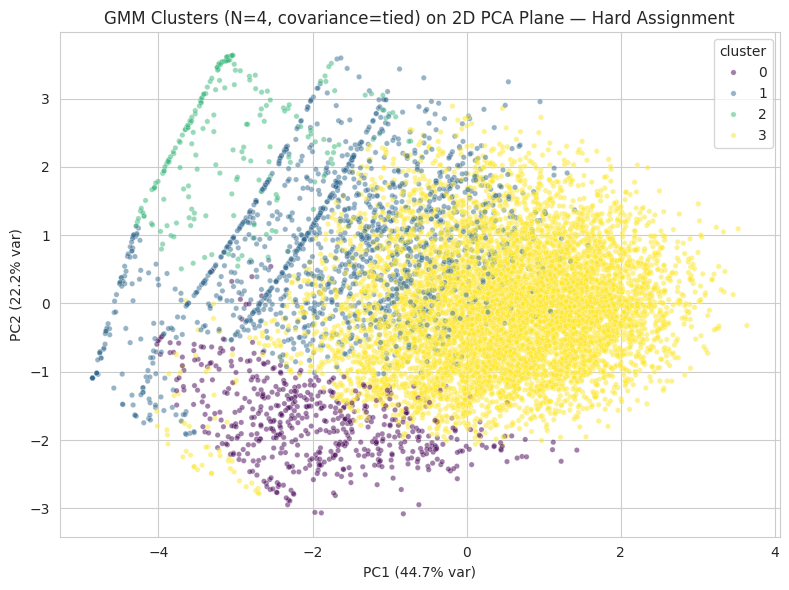

In [9]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pcs = pca.fit_transform(X)
df['PC1'], df['PC2'] = pcs[:, 0], pcs[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='PC1', y='PC2', hue='cluster', palette='viridis', alpha=0.5, s=15, legend='full')
plt.title(f'GMM Clusters (N={best_n}, covariance={best_cov}) on 2D PCA Plane — Hard Assignment')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/project/data/gmm_pca_scatter.png', dpi=110)
plt.show()


## 5. Export Artifacts

In [10]:
joblib.dump(best_model, '/content/drive/MyDrive/project/models/gmm_model.pkl')

gmm_results = {
    'algorithm': 'GaussianMixture',
    'assigned_member': 'Student 3',
    'grid_search_space': param_grid,
    'best_params': {'n_components': best_n, 'covariance_type': best_cov},
    'best_metrics': {
        'silhouette_score': float(best_row['silhouette']),
        'davies_bouldin_index': float(best_row['davies_bouldin']),
        'calinski_harabasz_index': float(best_row['calinski_harabasz']),
        'bic': float(best_row['bic']),
        'aic': float(best_row['aic']),
    },
    'best_by_bic': {'n_components': int(best_bic_row['n_components']), 'covariance_type': best_bic_row['covariance_type'], 'bic': float(best_bic_row['bic'])},
    'all_grid_results': results_df.to_dict(orient='records'),
    'cluster_sizes': df['cluster'].value_counts().sort_index().to_dict(),
}

with open('/content/drive/MyDrive/project/metrics/gmm_results.json', 'w') as f:
    json.dump(gmm_results, f, indent=2, default=str)

print("Saved /content/drive/MyDrive/project/models/gmm_model.pkl and metrics/gmm_results.json")


Saved /content/drive/MyDrive/project/models/gmm_model.pkl and metrics/gmm_results.json
